# ***Customer Churn Early Warning System***

## Problem Statement

***Goal:
Predict which customers are likely to churn and identify key factors behind churn.***

***Business Value:
Helps companies take proactive actions to retain customers.***

## Step-1: Importing the Libraries

In [1]:
# Import core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Step-2: Loading the Dataset

In [2]:
# Load dataset
df = pd.read_csv("churn.csv")

# Displaying the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step-3: Understanding the data

In [3]:
# Shape of dataset (rows, columns)
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types and missing values
df.info()

# Statistical summary
df.describe()

Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   Internet

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step-4: Data Cleaning

In [4]:
# Convert TotalCharges to numeric (it may contain spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing values
df.dropna(inplace=True)

# Convert target variable (Yes/No → 1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

df.head()


Missing Values:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Step-5: Exploratory Data Analysis (EDA)

***1) Churn Distribution***

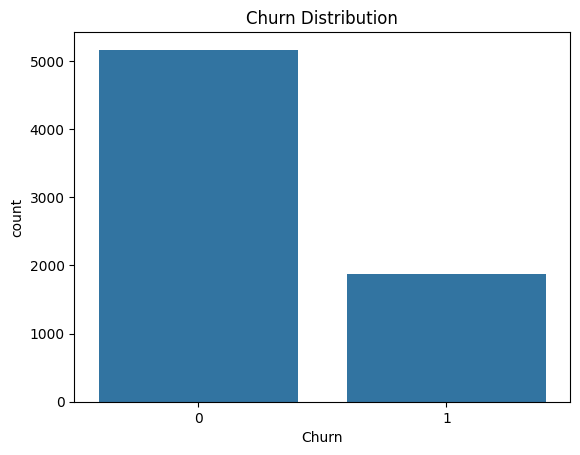

In [5]:
# Checking how many customers churned vs not
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

***2) Churn vs Contract Type***

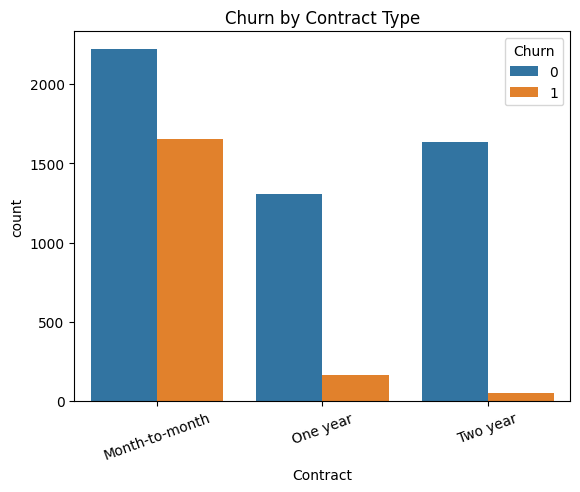

In [6]:
# Analyzing churn based on contract type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

***3) Monthly Charges vs Churn***

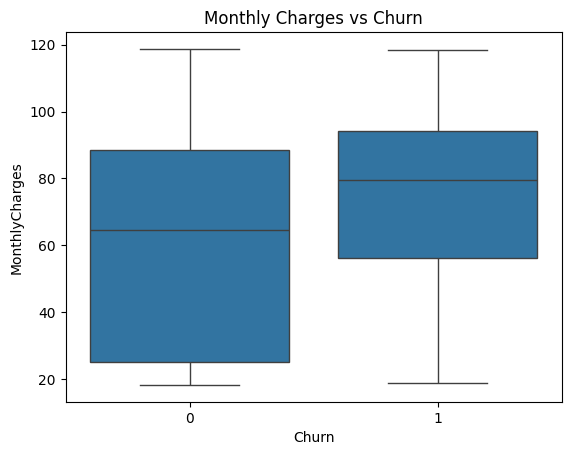

In [7]:
# Comparing monthly charges for churned vs non-churned customers
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

***4) Tenure Distribution***

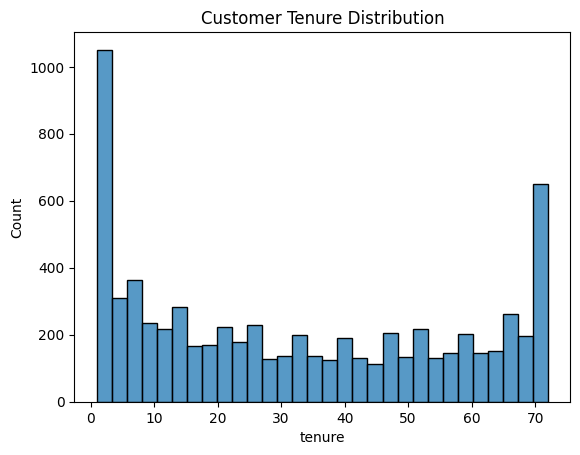

In [8]:
# Distribution of customer tenure
sns.histplot(df['tenure'], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

## Step-6: Feature Engineering

In [9]:
# Creating tenure groups (helps model to understand the patterns better)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,60,72],
    labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr']
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4yr
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr


## Step-7: Encoding Categorical Variables

In [10]:
# Converting categorical columns into numeric using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Check updated data
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,True,False,False,False,False,True,False,True,False,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,True,False,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False


## Step-8: Define Features & Target

In [11]:
# X = Features (input)
# y = Target (output)

X = df.drop('Churn', axis=1)
y = df['Churn']

## Step-9: Train-Test Split

In [12]:
# Split data into training and testing sets (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step-10: Model Training

In [13]:
# Initialize Random Forest model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step-11: Model Evaluation

In [14]:
# Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7796730632551528

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.46      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



## Step-12: Confusion Matrix

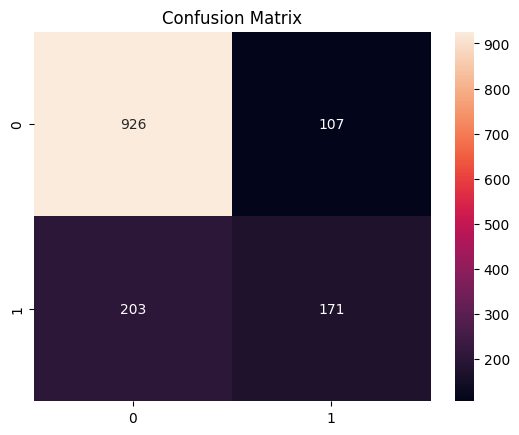

In [15]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")

# Save image
plt.savefig("outputs/confusion_matrix.png", bbox_inches='tight')

plt.show()

## Step-13: Feature Importance

In [16]:
# Extract feature importance from model
importances = model.feature_importances_
features = X.columns

# Create dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 important features
importance_df.head(10)

,Feature,Importance
3,TotalCharges,0.180514
2,MonthlyCharges,0.161514
1,tenure,0.158646
10,InternetService_Fiber optic,0.037500
28,PaymentMethod_Electronic check,0.034621
4,gender_Male,0.027815
25,Contract_Two year,0.026820
26,PaperlessBilling_Yes,0.026163
13,OnlineSecurity_Yes,0.025686
5,Partner_Yes,0.023927


***Plot Feature Importance***

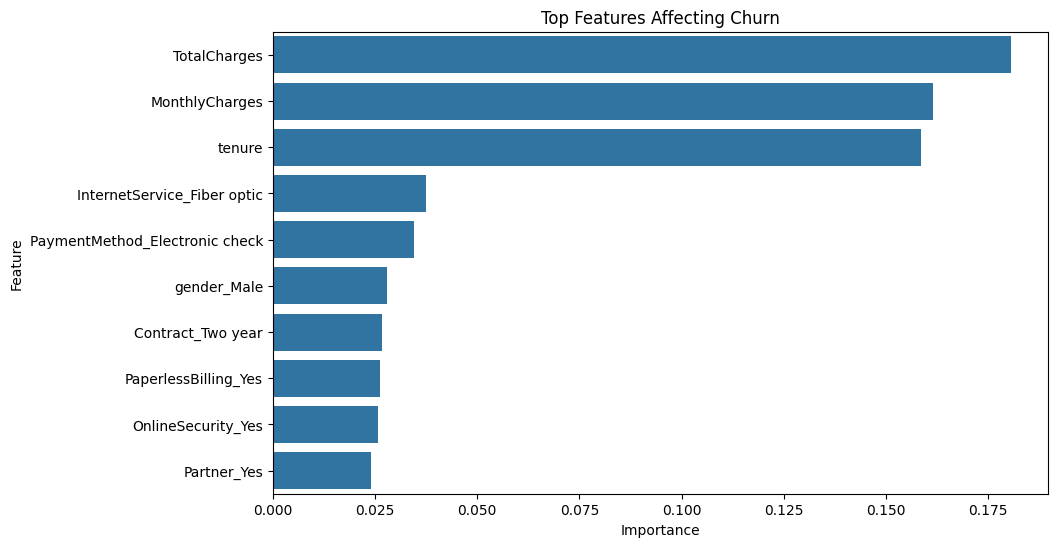

In [17]:
# Plot top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top Features Affecting Churn")

# Save image
plt.savefig("outputs/feature_importance.png", bbox_inches='tight')

plt.show()

## Step-14: Predict Churn Probability

In [18]:
# Get probability of churn (not just 0/1 prediction)
df['churn_probability'] = model.predict_proba(X)[:,1]

# Show top customers likely to churn
df[['churn_probability']].sort_values(by='churn_probability', ascending=False).head()

,churn_probability
4789,1.0
3346,1.0
6933,1.0
2269,1.0
2797,1.0


## Step-15: Identify High-Risk Customers

In [19]:
# Customers with high churn probability (> 70%)
high_risk = df[df['churn_probability'] > 0.7]

# Display them
high_risk.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr,churn_probability
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,True,False,False,True,False,False,False,False,0.80
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,True,False,True,False,False,False,False,False,0.89
5,0,8,99.65,820.50,1,False,False,False,True,False,...,False,True,False,True,False,False,False,False,False,0.97
13,0,49,103.70,5036.30,1,True,False,False,True,False,...,False,True,False,False,False,False,False,True,False,0.81
18,0,10,55.20,528.35,1,False,True,True,True,False,...,False,False,True,False,False,False,False,False,False,0.77


## Step-16: Insights

### Key Insights

- Customers with month-to-month contracts churn more
- Higher monthly charges increase churn probability
- Customers with low tenure are more likely to churn
- Lack of tech support and security increases churn risk

## Step-17: Business Recommendations

### Business Recommendations

- Encourage long-term contracts with discounts
- Focus retention campaigns on new customers
- Provide bundled services (security + support)
- Target high-risk customers identified by the model

In [20]:
import os

# Create outputs folder
os.makedirs("outputs", exist_ok=True)